## README:

This notebook evaluates the performance of the trained RL agents on the test set using a set of financial metrics.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

In [2]:
# add project root to path
root_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(root_path)

In [3]:
from evaluation import financial_metrics

In [4]:
load_dotenv(r'../.env')

DATA_DIR = os.getenv('DATA_DIR')

## Prepare backtest results

In [5]:
# RecurrentPPO+LSTM with MLP feature extractor
base_pnl = pd.read_csv(os.path.join(DATA_DIR, 'base_pnl_20251214_2353.csv'))
base_pen_0005 = pd.read_csv(os.path.join(DATA_DIR, 'base_penalized_0.005_20251214_2343.csv'))

# PPO with MAMBA feature extractor
mamba_pnl = pd.read_csv(os.path.join(DATA_DIR, 'mamba_pnl_20251214_1012.csv'))
mamba_pen_010 = pd.read_csv(os.path.join(DATA_DIR, 'mamba_penalized_0.10_20251214_1550.csv'))
mamba_pen_005 = pd.read_csv(os.path.join(DATA_DIR, 'mamba_penalized_0.05_20251214_1731.csv'))
mamba_pen_0005 = pd.read_csv(os.path.join(DATA_DIR, 'mamba_penalized_0.005_20251214_2038.csv'))
mamba_pen_0001 = pd.read_csv(os.path.join(DATA_DIR, 'mamba_penalized_0.001_20251214_1911.csv'))

In [6]:
window_size = 50

# trading begins after window_size steps
# i.e. first state is at idx = window_size - 1
base_pnl = base_pnl.iloc[window_size-1:, :].reset_index(drop=True)
base_pen_0005 = base_pen_0005.iloc[window_size-1:, :].reset_index(drop=True)
mamba_pnl = mamba_pnl.iloc[window_size-1:, :].reset_index(drop=True)
mamba_pen_010 = mamba_pen_010.iloc[window_size-1:, :].reset_index(drop=True)
mamba_pen_005 = mamba_pen_005.iloc[window_size-1:, :].reset_index(drop=True)
mamba_pen_0005 = mamba_pen_0005.iloc[window_size-1:, :].reset_index(drop=True)
mamba_pen_0001 = mamba_pen_0001.iloc[window_size-1:, :].reset_index(drop=True)

In [7]:
price_cols = [col for col in base_pnl.columns if 'price' in col]
share_cols = [col for col in base_pnl.columns if 'share' in col]

## Generate metrics

In [8]:
metrics_base_pnl = financial_metrics.financial_performance(base_pnl)
metrics_base_pen_0005 = financial_metrics.financial_performance(base_pen_0005)
metrics_mamba_pnl = financial_metrics.financial_performance(mamba_pnl)
metrics_mamba_pen_010 = financial_metrics.financial_performance(mamba_pen_010)
metrics_mamba_pen_005 = financial_metrics.financial_performance(mamba_pen_005)
metrics_mamba_pen_0005 = financial_metrics.financial_performance(mamba_pen_0005)
metrics_mamba_pen_0001 = financial_metrics.financial_performance(mamba_pen_0001)

metrics_df = pd.DataFrame([
    metrics_base_pnl,
    metrics_base_pen_0005,
    metrics_mamba_pnl,
    metrics_mamba_pen_010,
    metrics_mamba_pen_005,
    metrics_mamba_pen_0005,
    metrics_mamba_pen_0001
]).T

metrics_df.columns = [
    'base_pnl', 'base_pen_0.005',
    'mamba_pnl', 'mamba_pen_0.10', 'mamba_pen_0.05', 'mamba_pen_0.005', 'mamba_pen_0.001'
]

metrics_df.round(3).T

,total_return,CAGR,volatility,Sharpe,VaR,turnover
base_pnl,5.590,0.277,0.310,0.943,0.030,0.000
base_pen_0.005,5.590,0.277,0.310,0.943,0.030,0.000
mamba_pnl,1.989,0.152,0.300,0.622,0.027,0.009
mamba_pen_0.10,0.774,0.077,0.399,0.385,0.036,0.000
mamba_pen_0.05,1.956,0.151,0.208,0.781,0.019,0.003
mamba_pen_0.005,5.590,0.277,0.310,0.943,0.030,0.000
mamba_pen_0.001,1.542,0.128,0.212,0.677,0.018,0.004


In [9]:
# generate metrics on stock prices
stock_eval = []
for col in price_cols:
    series = base_pnl[col].values
    stock_eval.append({
        'stock': col,
        'return': financial_metrics.get_total_return(series),
        'sharpe': financial_metrics.get_sharpe_ratio(series)
    })
stock_eval = pd.DataFrame(stock_eval)
stock_eval.sort_values('return', ascending=False).round(3)

,stock,return,sharpe
5,price_NVDA,29.154,1.113
0,price_AAPL,5.623,0.945
4,price_MSFT,4.662,0.932
3,price_JPM,2.395,0.688
1,price_AMZN,1.852,0.565
7,price_SPY,1.805,0.782
9,price_XOM,1.249,0.498
6,price_PG,1.148,0.595
2,price_F,0.783,0.387
8,price_UNH,0.627,0.360


## Visualize trading

In [10]:
def visualize_trading(df):
    n_stocks = df.shape[1]

    fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(10, 0.8 * n_stocks), sharex=True)
    axes = axes.flatten()

    for ax, stock in zip(axes, df.columns):
        ax.plot(df.index, df[stock])
        ax.set_title(stock)
        ax.set_ylabel("Shares")
        ax.yaxis.set_major_locator(plt.MaxNLocator(5))

    axes[-1].set_xlabel("Time")
    plt.tight_layout()
    plt.show()

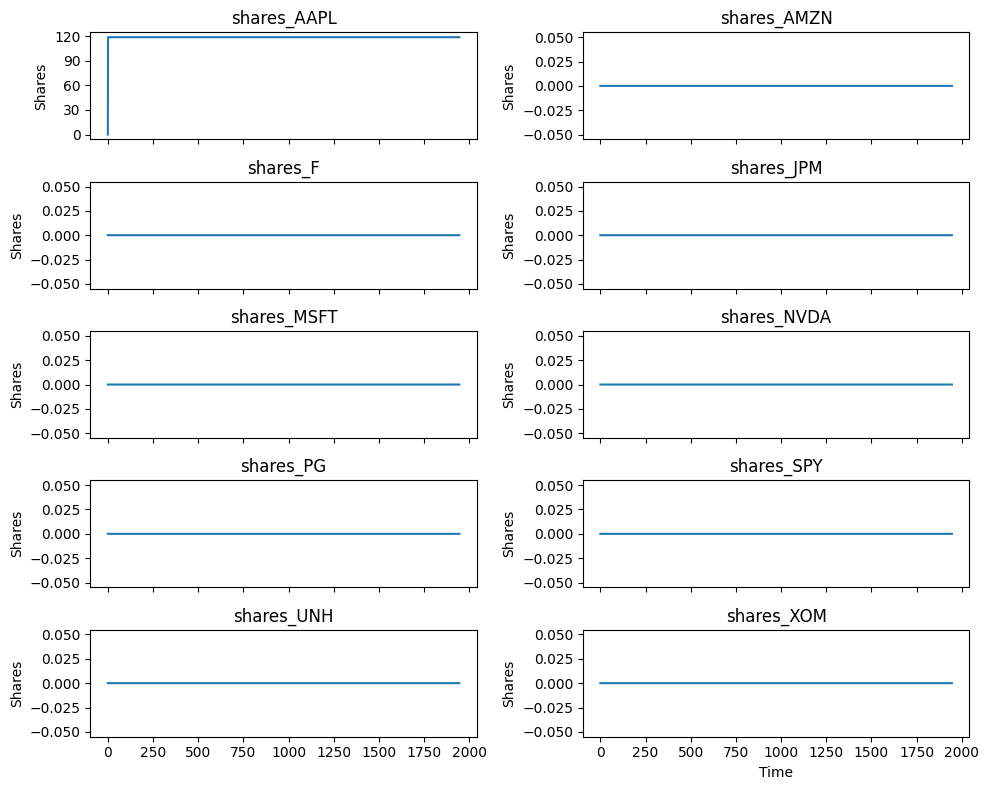

In [11]:
visualize_trading(base_pnl[share_cols])

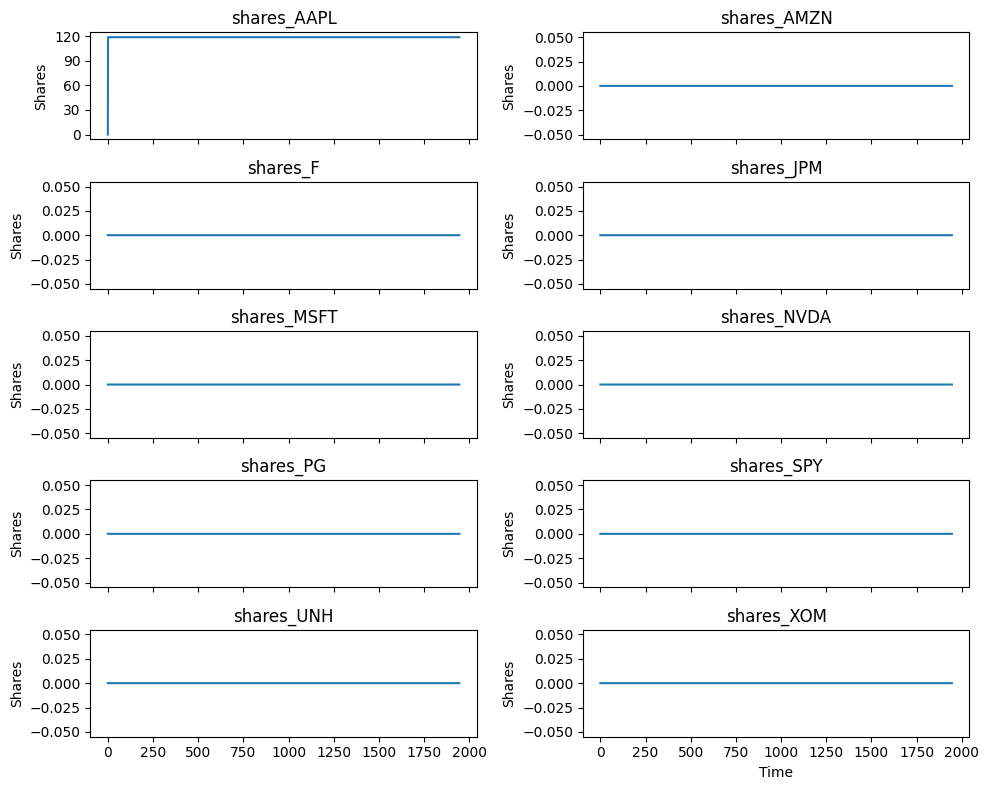

In [12]:
visualize_trading(base_pen_0005[share_cols])

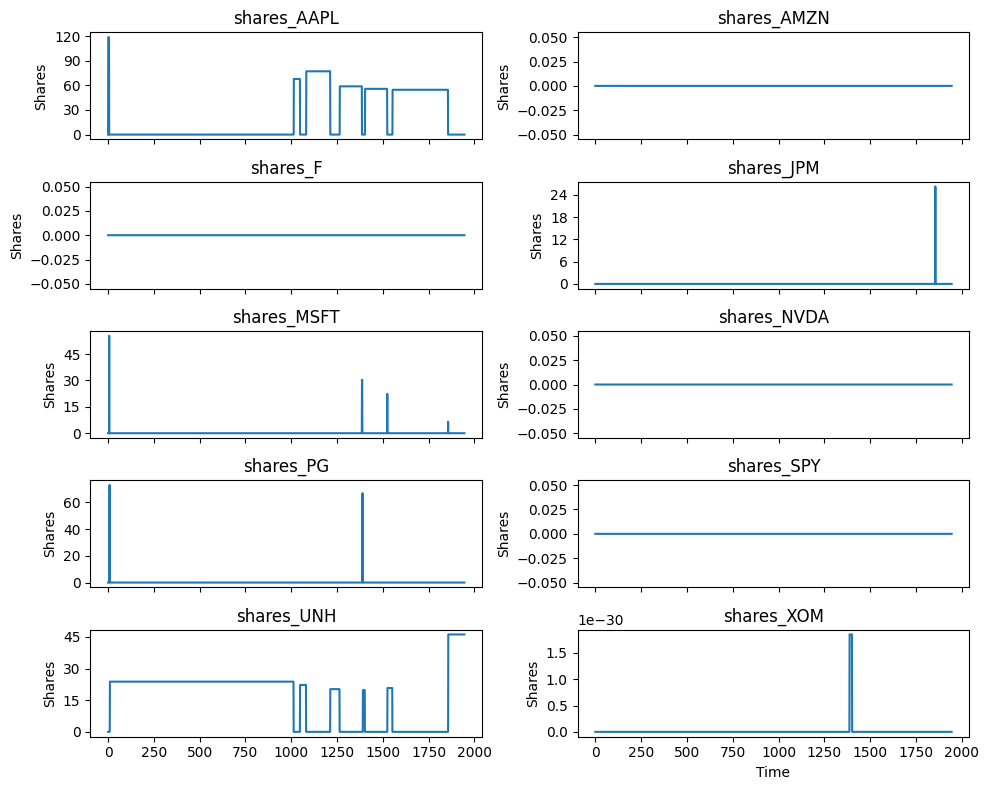

In [13]:
visualize_trading(mamba_pnl[share_cols])

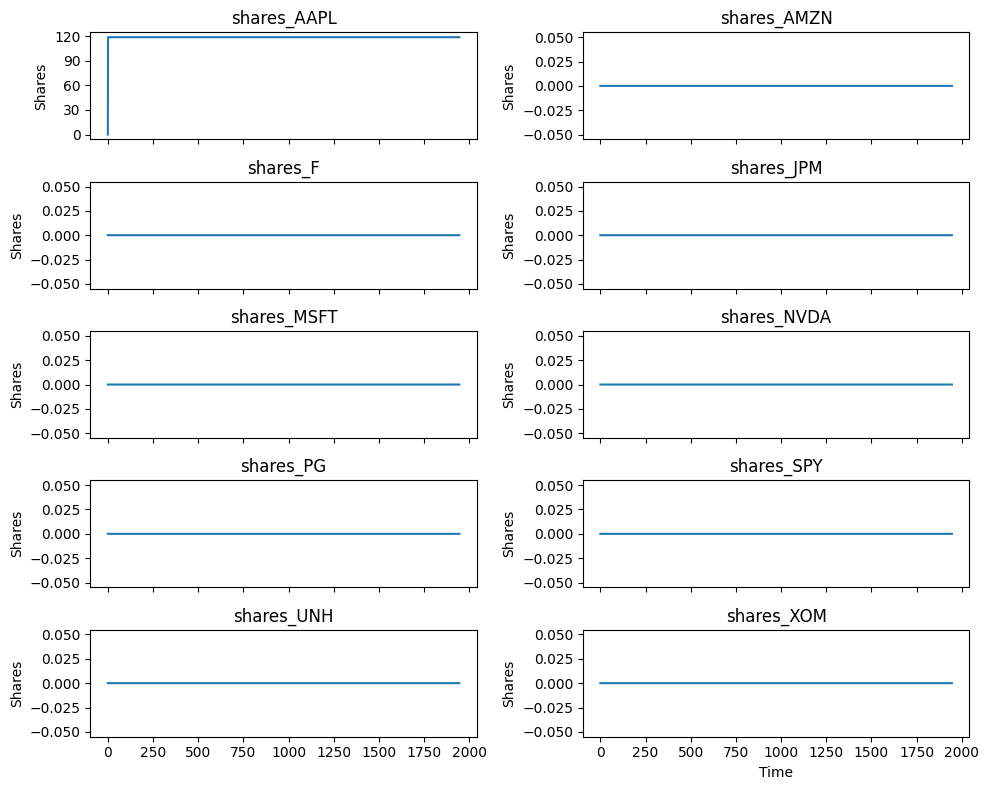

In [14]:
visualize_trading(mamba_pen_0005[share_cols])